# Feature Engineering + Embeddings
**Trump Posts vs S&P 500 — NLP Final Assignment**

### Structure
1. Load preprocessed data
2. Tweet-level features
   - 2a. VADER sentiment
   - 2b. FinBERT sentiment (batched)
   - 2c. Topic keyword flags
   - 2d. Structural / stylistic features
3. Daily aggregation
4. Market-side feature engineering
5. Embeddings
   - 5a. Sentence embeddings (`all-MiniLM-L6-v2`)
   - 5b. Semantic clustering (K-Means + HDBSCAN)
   - 5c. Daily mean embeddings as model features
   - 5d. Novelty score
   - 5e. UMAP visualisation
6. Final merge & save

---
## 0 — Imports & Setup

In [7]:
# Uncomment and run once to install all dependencies
# !pip install transformers datasets torch vaderSentiment sentence-transformers umap-learn hdbscan --quiet

In [8]:
from pathlib import Path
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

# Embeddings
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cosine as cosine_distance
import umap

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("All imports OK")

All imports OK


---
## 1 — Load Preprocessed Data

In [9]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "2_preprocessing" / "processed").exists():
            return p
    raise FileNotFoundError("Project folder not found.")

PROJECT_ROOT  = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "2_preprocessing" / "processed"
OUTPUT_DIR    = PROJECT_ROOT / "3_feature_engineering" / "features"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tweets      = pd.read_pickle(PROCESSED_DIR / "tweets_processed.pkl")
daily_posts = pd.read_csv(PROCESSED_DIR / "daily_posts.csv",   parse_dates=["date"])
sp500       = pd.read_csv(PROCESSED_DIR / "sp500_aligned.csv", parse_dates=["date"])

print("tweets:     ", tweets.shape)
print("daily_posts:", daily_posts.shape)
print("sp500:      ", sp500.shape)
print("\nsp500 columns:", sp500.columns.tolist())

tweets:      (90551, 28)
daily_posts: (6094, 11)
sp500:       (4198, 10)

sp500 columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'daily_return', 'abs_return', 'intraday_range_pct', 'next_day_return']


In [10]:
# Work with original posts only (exclude reposts) to capture Trump's own voice
originals = tweets[tweets["repost_flag"] == False].copy()

# Ensure datetime and extract useful time components
originals["date"] = pd.to_datetime(originals["date"], utc=True).dt.tz_convert("US/Eastern")
originals["date_only"] = originals["date"].dt.date
originals["hour"]      = originals["date"].dt.hour
originals["weekday"]   = originals["date"].dt.dayofweek  # 0=Mon, 6=Sun

print(f"Original (non-repost) tweets: {len(originals):,}")
originals[["text", "date", "hour", "platform"]].head()

Original (non-repost) tweets: 74,742


,text,date,hour,platform
0,Be sure to tune in and watch Donald Trump on L...,2009-05-04 14:54:25-04:00,14,Twitter
1,Donald Trump will be appearing on The View tom...,2009-05-04 21:00:10-04:00,21,Twitter
2,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 09:38:08-04:00,9,Twitter
3,New Blog Post: Celebrity Apprentice Finale and...,2009-05-08 16:40:15-04:00,16,Twitter
4,"""My persona will never be that of a wallflower...",2009-05-12 10:07:28-04:00,10,Twitter


---
## 2a — VADER Sentiment

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based model
specifically designed for social media text. It handles caps, punctuation, and slang
well without needing training data (Hutto & Gilbert, 2014).

Outputs four scores per tweet:
- `vader_pos`, `vader_neg`, `vader_neu`: proportion of text in each class
- `vader_compound`: normalised aggregate score in [-1, +1]

In [11]:
vader = SentimentIntensityAnalyzer()

def get_vader_scores(text: str) -> dict:
    """Return VADER scores for a single text string."""
    if not isinstance(text, str) or text.strip() == "":
        return {"vader_neg": np.nan, "vader_neu": np.nan,
                "vader_pos": np.nan, "vader_compound": np.nan}
    scores = vader.polarity_scores(text)
    return {
        "vader_neg":      scores["neg"],
        "vader_neu":      scores["neu"],
        "vader_pos":      scores["pos"],
        "vader_compound": scores["compound"],
    }

vader_scores = originals["text"].apply(get_vader_scores)
vader_df     = pd.DataFrame(list(vader_scores), index=originals.index)
originals    = pd.concat([originals, vader_df], axis=1)

# Categorical label based on compound threshold (standard cutoffs)
def vader_label(compound):
    if pd.isna(compound):   return np.nan
    if compound >= 0.05:    return "positive"
    if compound <= -0.05:   return "negative"
    return "neutral"

originals["vader_label"] = originals["vader_compound"].apply(vader_label)

print("VADER label distribution:")
print(originals["vader_label"].value_counts())
originals[["text", "vader_compound", "vader_label"]].head()

VADER label distribution:
vader_label
positive    35460
neutral     22680
negative    16602
Name: count, dtype: int64


,text,vader_compound,vader_label
0,Be sure to tune in and watch Donald Trump on L...,0.5255,positive
1,Donald Trump will be appearing on The View tom...,0.7712,positive
2,Donald Trump reads Top Ten Financial Tips on L...,0.6468,positive
3,New Blog Post: Celebrity Apprentice Finale and...,0.0000,neutral
4,"""My persona will never be that of a wallflower...",0.0000,neutral


---
## 2b — FinBERT Sentiment (Batched)

FinBERT is a BERT-based model fine-tuned on financial text (Araci, 2019).
It is better at capturing the financial connotation of words like "tariff" or "deficit"
that VADER may mislabel.

We use the `ProsusAI/finbert` checkpoint from HuggingFace.

> **Note:** This cell may take 5-20 minutes depending on hardware.
> Use a GPU if available. Set `FINBERT_ENABLED = False` to skip and use VADER only.

In [12]:
FINBERT_ENABLED = True   # Set False to skip
BATCH_SIZE      = 64
MAX_LEN         = 512    # FinBERT token limit

if FINBERT_ENABLED:
    print("Loading FinBERT pipeline...")
    finbert_pipe = pipeline(
        "text-classification",
        model="ProsusAI/finbert",
        tokenizer="ProsusAI/finbert",
        truncation=True,
        max_length=MAX_LEN,
        top_k=None,          # return all three class scores
        device=-1,           # -1 = CPU; change to 0 for first GPU
    )

    texts = originals["text"].fillna("").tolist()

    # Run in batches and collect results
    all_results = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]
        all_results.extend(finbert_pipe(batch))
        if (i // BATCH_SIZE) % 20 == 0:
            print(f"  Processed {i:,} / {len(texts):,}")

    def parse_finbert(result_list):
        """Convert list-of-dicts from top_k=None into a flat dict."""
        d = {r["label"]: r["score"] for r in result_list}
        return {
            "finbert_pos":      d.get("positive", np.nan),
            "finbert_neg":      d.get("negative", np.nan),
            "finbert_neu":      d.get("neutral",  np.nan),
            "finbert_label":    max(d, key=d.get),
            "finbert_polarity": d.get("positive", 0) - d.get("negative", 0),
        }

    finbert_rows = [parse_finbert(r) for r in all_results]
    finbert_df   = pd.DataFrame(finbert_rows, index=originals.index)
    originals    = pd.concat([originals, finbert_df], axis=1)

    print("\nFinBERT label distribution:")
    print(originals["finbert_label"].value_counts())

else:
    print("FinBERT skipped. Only VADER scores will be used downstream.")
    for col in ["finbert_pos", "finbert_neg", "finbert_neu",
                "finbert_label", "finbert_polarity"]:
        originals[col] = np.nan

Loading FinBERT pipeline...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 57121.42it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Processed 0 / 74,742
  Processed 1,280 / 74,742
  Processed 2,560 / 74,742
  Processed 3,840 / 74,742
  Processed 5,120 / 74,742
  Processed 6,400 / 74,742
  Processed 7,680 / 74,742
  Processed 8,960 / 74,742
  Processed 10,240 / 74,742
  Processed 11,520 / 74,742
  Processed 12,800 / 74,742
  Processed 14,080 / 74,742
  Processed 15,360 / 74,742
  Processed 16,640 / 74,742
  Processed 17,920 / 74,742
  Processed 19,200 / 74,742
  Processed 20,480 / 74,742
  Processed 21,760 / 74,742
  Processed 23,040 / 74,742
  Processed 24,320 / 74,742
  Processed 25,600 / 74,742
  Processed 26,880 / 74,742
  Processed 28,160 / 74,742
  Processed 29,440 / 74,742
  Processed 30,720 / 74,742
  Processed 32,000 / 74,742
  Processed 33,280 / 74,742
  Processed 34,560 / 74,742
  Processed 35,840 / 74,742
  Processed 37,120 / 74,742
  Processed 38,400 / 74,742
  Processed 39,680 / 74,742
  Processed 40,960 / 74,742
  Processed 42,240 / 74,742
  Processed 43,520 / 74,742
  Processed 44,800 / 74,742
  Pr

---
## 2c — Topic Keyword Flags

Binary flags for market-relevant topics. Each flag is 1 if the post text contains
any keyword in that topic group. Based on Molnar et al. (2021) and JP Morgan's
Volfefe index methodology.

In [13]:
TOPIC_KEYWORDS = {
    "topic_trade": [
        "tariff", "trade", "china", "import", "export", "duty",
        "bilateral", "deficit", "surplus", "wto", "nafta", "usmca",
        "intellectual property", "steel", "aluminum",
    ],
    "topic_fed": [
        "fed", "federal reserve", "interest rate", "powell", "inflation",
        "rate cut", "rate hike", "quantitative", "monetary policy",
        "basis point", "fomc",
    ],
    "topic_energy": [
        "oil", "gas", "pipeline", "energy", "opec", "lng", "petroleum",
        "fuel", "drill", "fracking", "keystone",
    ],
    "topic_tax": [
        "tax", "cut", "irs", "reform", "deduction", "corporate tax",
        "tax cut", "tax rate",
    ],
    "topic_sanctions": [
        "sanction", "ban", "restrict", "enemy", "terrorist", "tariff",
        "embargo", "penalty", "threat", "punish",
    ],
    "topic_market_direct": [
        "stock", "market", "economy", "jobs", "gdp", "unemployment",
        "dow", "nasdaq", "s&p", "wall street", "growth", "recession",
        "boom", "bust",
    ],
    "topic_immigration": [
        "immigration", "border", "wall", "immigrant", "illegal",
        "asylum", "deportation", "visa",
    ],
    "topic_geopolitics": [
        "russia", "ukraine", "nato", "iran", "north korea", "missile",
        "nuclear", "war", "military", "troops",
    ],
}

def make_topic_flag(text: str, keywords: list) -> int:
    """Return 1 if any keyword appears in lowercased text."""
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return int(any(kw in text_lower for kw in keywords))

for topic, keywords in TOPIC_KEYWORDS.items():
    originals[topic] = originals["text"].apply(
        lambda t, kws=keywords: make_topic_flag(t, kws)
    )

topic_cols = list(TOPIC_KEYWORDS.keys())
print("Topic flag counts (how many posts mention each topic):")
print(originals[topic_cols].sum().sort_values(ascending=False))

Topic flag counts (how many posts mention each topic):
topic_geopolitics      6881
topic_market_direct    5168
topic_tax              5044
topic_immigration      3967
topic_trade            3339
topic_sanctions        2478
topic_energy           1858
topic_fed              1472
dtype: int64


---
## 2d — Structural / Stylistic Features

In [14]:
def caps_ratio(text: str) -> float:
    """Fraction of alphabetic characters that are uppercase."""
    if not isinstance(text, str) or len(text) == 0:
        return np.nan
    alpha = [c for c in text if c.isalpha()]
    if len(alpha) == 0:
        return 0.0
    return sum(1 for c in alpha if c.isupper()) / len(alpha)

originals["caps_ratio"]        = originals["text"].apply(caps_ratio)
originals["exclamation_count"] = originals["text"].str.count(r"!")
originals["question_count"]    = originals["text"].str.count(r"\?")
originals["mention_count"]     = originals["text"].str.count(r"@\w+")
originals["hashtag_count"]     = originals["text"].str.count(r"#\w+")
originals["url_flag"]          = originals["text"].str.contains(
    r"http[s]?://", na=False).astype(int)

# Engagement: log-transform to reduce skew
originals["log_engagement"] = np.log1p(
    originals["favorite_count"].fillna(0) + originals["repost_count"].fillna(0)
)

# Timing flags (US Eastern time)
originals["is_premarket"]    = originals["hour"].between(4, 9).astype(int)
originals["is_afterhours"]   = (originals["hour"] >= 16).astype(int)
originals["is_market_hours"] = (
    (originals["hour"] == 9) | originals["hour"].between(10, 15)
).astype(int)

print("Structural features added. Sample:")
originals[["text", "caps_ratio", "exclamation_count", "log_engagement", "is_premarket"]].head()

Structural features added. Sample:


,text,caps_ratio,exclamation_count,log_engagement,is_premarket
0,Be sure to tune in and watch Donald Trump on L...,0.1064,1,7.2786,0
1,Donald Trump will be appearing on The View tom...,0.0917,1,5.6836,0
2,Donald Trump reads Top Ten Financial Tips on L...,0.1196,1,3.8918,1
3,New Blog Post: Celebrity Apprentice Finale and...,0.1205,0,3.5835,0
4,"""My persona will never be that of a wallflower...",0.0610,0,8.0864,0


---
## 3 — Daily Aggregation

In [15]:
def daily_agg(df: pd.DataFrame, suffix: str = "") -> pd.DataFrame:
    """
    Aggregate tweet-level features to daily level.
    suffix: appended to column names to distinguish all-day vs pre-market.
    """
    agg = df.groupby("date_only").agg(
        post_count       = ("text", "count"),
        vader_mean       = ("vader_compound", "mean"),
        vader_std        = ("vader_compound", "std"),
        vader_max_pos    = ("vader_compound", "max"),
        vader_max_neg    = ("vader_compound", "min"),
        finbert_mean     = ("finbert_polarity", "mean"),
        finbert_std      = ("finbert_polarity", "std"),
        caps_ratio_mean  = ("caps_ratio", "mean"),
        exclamation_mean = ("exclamation_count", "mean"),
        exclamation_max  = ("exclamation_count", "max"),
        max_engagement   = ("log_engagement", "max"),
        mean_word_count  = ("word_count", "mean"),
        **{t: (t, "max") for t in TOPIC_KEYWORDS.keys()},
    ).reset_index()

    agg["date_only"] = pd.to_datetime(agg["date_only"])

    if suffix:
        rename_map = {c: f"{c}{suffix}" for c in agg.columns if c != "date_only"}
        agg = agg.rename(columns=rename_map)

    return agg

# All-day aggregation
daily_all = daily_agg(originals, suffix="")

# Pre-market only (posts before 9:30 AM ET)
premarket  = originals[originals["is_premarket"] == 1]
daily_pre  = daily_agg(premarket, suffix="_premarket")

# Merge
daily_features = daily_all.merge(daily_pre, on="date_only", how="left")

print("Daily features shape:", daily_features.shape)
daily_features.head()

Daily features shape: (4867, 41)


,date_only,post_count,vader_mean,vader_std,vader_max_pos,vader_max_neg,finbert_mean,finbert_std,caps_ratio_mean,exclamation_mean,exclamation_max,max_engagement,mean_word_count,topic_trade,topic_fed,topic_energy,topic_tax,topic_sanctions,topic_market_direct,topic_immigration,topic_geopolitics,post_count_premarket,vader_mean_premarket,vader_std_premarket,vader_max_pos_premarket,vader_max_neg_premarket,finbert_mean_premarket,finbert_std_premarket,caps_ratio_mean_premarket,exclamation_mean_premarket,exclamation_max_premarket,max_engagement_premarket,mean_word_count_premarket,topic_trade_premarket,topic_fed_premarket,topic_energy_premarket,topic_tax_premarket,topic_sanctions_premarket,topic_market_direct_premarket,topic_immigration_premarket,topic_geopolitics_premarket
0,2009-05-04,2,0.6483,0.1737,0.7712,0.5255,0.0418,0.0046,0.0991,1.0000,1,7.2786,22.5000,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-05-08,2,0.3234,0.4574,0.6468,0.0000,0.0508,0.0177,0.1200,0.5000,1,3.8918,15.0000,0,0,0,0,0,0,0,0,1.0000,0.6468,NaN,0.6468,0.6468,0.0383,NaN,0.1196,1.0000,1.0000,3.8918,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,2009-05-12,2,0.2404,0.3400,0.4809,0.0000,-0.1093,0.1675,0.0847,0.0000,0,8.0864,20.5000,0,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-05-13,1,0.7506,NaN,0.7506,0.7506,0.0848,NaN,0.0778,0.0000,0,3.4657,16.0000,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-05-14,1,0.2023,NaN,0.2023,0.2023,0.0137,NaN,0.0500,0.0000,0,3.7377,14.0000,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Rolling sentiment windows (3-day and 7-day)
daily_features = daily_features.sort_values("date_only").reset_index(drop=True)

daily_features["vader_3d_rolling"] = (
    daily_features["vader_mean"].rolling(window=3, min_periods=1).mean()
)
daily_features["vader_7d_rolling"] = (
    daily_features["vader_mean"].rolling(window=7, min_periods=1).mean()
)

# Sentiment momentum: today vs 3-day rolling average
daily_features["vader_momentum"] = (
    daily_features["vader_mean"] - daily_features["vader_3d_rolling"]
)

print("Rolling features added.")
daily_features[["date_only", "vader_mean", "vader_3d_rolling", "vader_7d_rolling", "vader_momentum"]].head(10)

Rolling features added.


,date_only,vader_mean,vader_3d_rolling,vader_7d_rolling,vader_momentum
0,2009-05-04,0.6483,0.6483,0.6483,0.0000
1,2009-05-08,0.3234,0.4859,0.4859,-0.1625
2,2009-05-12,0.2404,0.4041,0.4041,-0.1636
3,2009-05-13,0.7506,0.4382,0.4907,0.3125
4,2009-05-14,0.2023,0.3978,0.4330,-0.1955
5,2009-05-15,0.7506,0.5678,0.4860,0.1828
6,2009-05-16,0.0000,0.3176,0.4165,-0.3176
7,2009-05-17,0.7717,0.5074,0.4342,0.2643
8,2009-05-18,0.5859,0.4525,0.4717,0.1334
9,2009-05-19,0.0000,0.4525,0.4373,-0.4525


---
## 4 — Market-Side Feature Engineering

Your S&P CSV already has several pre-computed columns (`daily_return`, `abs_return`,
`intraday_range_pct`, `next_day_return`), so we reuse those and just rename
to match the rest of the notebook. We add lagged returns and rolling volatility.

In [ ]:
sp = sp500.sort_values("date").copy()

# Rename lowercase columns
sp = sp.rename(columns={
    "close":              "Close",
    "high":               "High",
    "low":                "Low",
    "open":               "Open",
    "volume":             "Volume",
    "daily_return":       "log_return",      # already computed in preprocessing
    "abs_return":         "abs_return",
    "intraday_range_pct": "intraday_range",
    "next_day_return":    "next_log_return",  # already shifted in preprocessing
})

# Classification targets
sp["market_up"]      = (sp["log_return"] > 0).astype(int)
sp["next_market_up"] = (sp["next_log_return"] > 0).astype(int)

# Lagged returns (controls for autocorrelation)
sp["return_lag1"] = sp["log_return"].shift(1)
sp["return_lag2"] = sp["log_return"].shift(2)

# Realised volatility: rolling std of returns
sp["vol_5d"]  = sp["log_return"].rolling(5).std()
sp["vol_20d"] = sp["log_return"].rolling(20).std()

print("Market features computed. Sample:")
sp[["date", "Close", "log_return", "market_up", "next_log_return", "vol_5d"]].head(10)

Market features computed. Sample:


,date,Close,log_return,market_up,next_log_return,vol_5d
0,2009-05-04,907.2400,0.0339,1,-0.0038,NaN
1,2009-05-05,903.8000,-0.0038,0,0.0174,NaN
2,2009-05-06,919.5300,0.0174,1,-0.0132,NaN
3,2009-05-07,907.3900,-0.0132,0,0.0241,NaN
4,2009-05-08,929.2300,0.0241,1,-0.0215,0.0196
5,2009-05-11,909.2400,-0.0215,0,-0.0010,0.0196
6,2009-05-12,908.3500,-0.0010,0,-0.0269,0.0195
7,2009-05-13,883.9200,-0.0269,0,0.0104,0.0203
8,2009-05-14,893.0700,0.0104,1,-0.0114,0.0214
9,2009-05-15,882.8800,-0.0114,0,0.0304,0.0151


---
## 5 — Embeddings

Dense vector representations open up three things beyond VADER/FinBERT:
1. **Data-driven topic discovery** via clustering — no hand-crafted keyword lists needed
2. **Daily mean embedding** as a rich feature vector for downstream models
3. **Novelty score** — how semantically unusual is today's posting vs the recent baseline?

### 5a — Sentence Embeddings

We use `all-MiniLM-L6-v2` (Reimers & Gurevych, 2019): 384 dimensions,
fast on CPU, optimised for semantic similarity.

Embeddings are cached to disk after the first run — re-running this cell is instant.

> **Runtime:** ~5-15 minutes on CPU for 90k tweets.

In [18]:
EMBEDDING_CACHE = OUTPUT_DIR / "tweet_embeddings.npy"
MODEL_NAME      = "all-MiniLM-L6-v2"

# Reset index so row position == embedding index
originals = originals.reset_index(drop=True)
originals["emb_idx"] = np.arange(len(originals))

texts = originals["text"].fillna("").tolist()

if EMBEDDING_CACHE.exists():
    print(f"Loading cached embeddings from {EMBEDDING_CACHE}")
    embeddings = np.load(EMBEDDING_CACHE)
else:
    print(f"Computing embeddings with '{MODEL_NAME}'...")
    emb_model  = SentenceTransformer(MODEL_NAME)
    embeddings = emb_model.encode(
        texts,
        batch_size=128,
        show_progress_bar=True,
        normalize_embeddings=True,  # unit-norm: cosine similarity = dot product
        convert_to_numpy=True,
    )
    np.save(EMBEDDING_CACHE, embeddings)
    print(f"Saved to {EMBEDDING_CACHE}")

print(f"Embedding matrix: {embeddings.shape}  ({embeddings.nbytes/1e6:.1f} MB)")

Computing embeddings with 'all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8242.33it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 584/584 [06:49<00:00,  1.43it/s]


Saved to c:\Dev\nlp-final-project\3_feature_engineering\features\tweet_embeddings.npy
Embedding matrix: (74742, 384)  (114.8 MB)


### 5b — Semantic Clustering: Data-Driven Topic Discovery

K-Means on the embeddings finds topics automatically — no keyword lists required.
We use the silhouette score to select K, then inspect representative tweets to
assign human-readable labels to each cluster.

Fitting K-Means for K = 5-20 on subsample...
  K= 5  silhouette=0.0640
  K= 6  silhouette=0.0675
  K= 7  silhouette=0.0712
  K= 8  silhouette=0.0732
  K= 9  silhouette=0.0754
  K=10  silhouette=0.0808
  K=11  silhouette=0.0764
  K=12  silhouette=0.0716
  K=13  silhouette=0.0889
  K=14  silhouette=0.0798
  K=15  silhouette=0.0848
  K=16  silhouette=0.1002
  K=17  silhouette=0.0874
  K=18  silhouette=0.0871
  K=19  silhouette=0.0907
  K=20  silhouette=0.0691


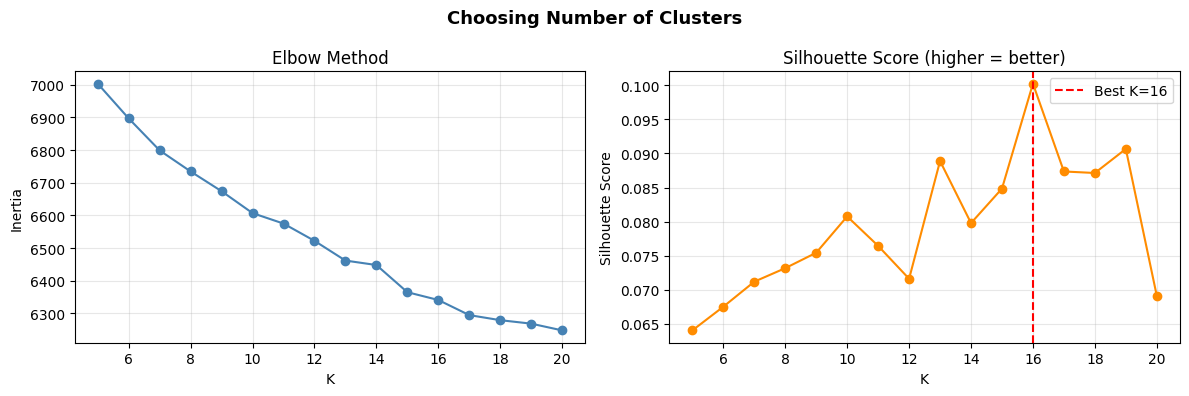

Best K by silhouette: 16


In [19]:
# Elbow + Silhouette on a subsample (silhouette is O(n^2), expensive on full corpus)
N_SAMPLE   = 10_000
rng        = np.random.default_rng(42)
idx_sample = rng.choice(len(embeddings), size=N_SAMPLE, replace=False)
emb_sample = embeddings[idx_sample]

K_RANGE     = range(5, 21)
inertias    = []
silhouettes = []

print("Fitting K-Means for K = 5-20 on subsample...")
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(emb_sample)
    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(emb_sample, labels, sample_size=3000, random_state=42)
    )
    print(f"  K={k:2d}  silhouette={silhouettes[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, marker="o", color="steelblue")
ax1.set(xlabel="K", ylabel="Inertia", title="Elbow Method")
ax1.grid(True, alpha=0.3)

best_k = list(K_RANGE)[np.argmax(silhouettes)]
ax2.plot(list(K_RANGE), silhouettes, marker="o", color="darkorange")
ax2.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
ax2.set(xlabel="K", ylabel="Silhouette Score", title="Silhouette Score (higher = better)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Choosing Number of Clusters", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best K by silhouette: {best_k}")

In [ ]:
# Fit K-Means on all embeddings with the chosen K
K = best_k  

print(f"Fitting K-Means (K={K}) on all {len(embeddings):,} tweets...")
kmeans         = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)
originals["cluster_kmeans"] = cluster_labels

print("Cluster sizes:")
print(originals["cluster_kmeans"].value_counts().sort_index())

Fitting K-Means (K=16) on all 74,742 tweets...
Cluster sizes:
cluster_kmeans
0     3487
1     3214
2     4820
3     6248
4     7388
5     3503
6     1581
7     2722
8     5323
9     9550
10    3322
11    2066
12    7002
13    5812
14    3666
15    5038
Name: count, dtype: int64


In [21]:
# Print the 5 most representative tweets per cluster (closest to centroid)
# Read the output below and fill in CLUSTER_LABELS in the next cell
N_EXAMPLES = 5

print("=" * 80)
print("CLUSTER INSPECTION — assign human labels in the next cell after reading these")
print("=" * 80)

for c in range(K):
    mask     = cluster_labels == c
    c_embs   = embeddings[mask]
    c_texts  = originals.loc[mask, "text"].values
    centroid = kmeans.cluster_centers_[c]
    sims     = c_embs @ centroid
    top_idx  = np.argsort(sims)[::-1][:N_EXAMPLES]

    print(f"\n{'─'*70}")
    print(f"Cluster {c:2d}  ({mask.sum():,} tweets)")
    print(f"{'─'*70}")
    for i, ti in enumerate(top_idx):
        print(f"  [{i+1}] {c_texts[ti][:200]}")

CLUSTER INSPECTION — assign human labels in the next cell after reading these

──────────────────────────────────────────────────────────────────────
Cluster  0  (3,487 tweets)
──────────────────────────────────────────────────────────────────────
  [1] [Image]
  [2] [Image]
  [3] [Image]
  [4] [Image]
  [5] [Image]

──────────────────────────────────────────────────────────────────────
Cluster  1  (3,214 tweets)
──────────────────────────────────────────────────────────────────────
  [1] @AaronPha_q Thanks.
  [2] @KarlLewis01 Soon--thanks.
  [3] @DavidBlanch Thanks (I think)!
  [4] @BobHapka @sdoocy Thanks!
  [5] @MichaelRubinton. Thanks.

──────────────────────────────────────────────────────────────────────
Cluster  2  (4,820 tweets)
──────────────────────────────────────────────────────────────────────
  [1] Great new polls! Thank you Nevada, North Carolina & Ohio. Join the MOVEMENT today & lets #MAGA!  http://www.DonaldJTrump.com  pic.twitter.com/NnHAEe8Daz
  [2] Major story that 

In [ ]:
# Assign human-readable labels after reading the cluster inspection above. TODO talk with chris diogo jose 

CLUSTER_LABELS = {
    0:  "trade_china",
    1:  "economy_jobs",
    2:  "media_attacks",
    3:  "immigration",
    4:  "elections",
    5:  "foreign_policy",
    6:  "rallies_campaign",
    7:  "fed_rates",
    8:  "praise_thanks",
    9:  "covid_health",
    # extend as needed based on your K
}

originals["cluster_label"] = originals["cluster_kmeans"].map(
    lambda c: CLUSTER_LABELS.get(c, f"cluster_{c}")
)

print("Cluster label distribution:")
print(originals["cluster_label"].value_counts())

Cluster label distribution:
cluster_label
covid_health        9550
elections           7388
cluster_12          7002
immigration         6248
cluster_13          5812
praise_thanks       5323
cluster_15          5038
media_attacks       4820
cluster_14          3666
foreign_policy      3503
trade_china         3487
cluster_10          3322
economy_jobs        3214
fed_rates           2722
cluster_11          2066
rallies_campaign    1581
Name: count, dtype: int64


### 5c — Daily Mean Embeddings as Model Features

Average all tweet embeddings per day into a single 384-dim vector.
Also compute within-day diversity (std of embeddings) — high value means
Trump posted about many different things that day.

In [23]:
daily_emb_rows = []

for date, group in originals.groupby("date_only"):
    idx      = group["emb_idx"].values
    embs     = embeddings[idx]              # shape: (n_posts_today, 384)
    mean_emb = embs.mean(axis=0)            # (384,)
    emb_std  = embs.std(axis=0).mean()      # scalar — within-day topic breadth
    dominant = group["cluster_label"].mode()[0]

    row = {"date_only": date, "emb_diversity": emb_std, "dominant_cluster": dominant}
    for dim, val in enumerate(mean_emb):
        row[f"emb_{dim}"] = val
    daily_emb_rows.append(row)

daily_embeddings = pd.DataFrame(daily_emb_rows)
daily_embeddings["date_only"] = pd.to_datetime(daily_embeddings["date_only"])

emb_cols   = [c for c in daily_embeddings.columns if c.startswith("emb_") and c != "emb_diversity"]
emb_matrix = daily_embeddings[emb_cols].values   # (n_days, 384)

print(f"Daily embedding matrix: {emb_matrix.shape}")

Daily embedding matrix: (4867, 384)


In [24]:
# Pre-market mean embedding (posts 4-9:29 AM ET only)
premarket_emb = originals[originals["is_premarket"] == 1].copy()

pre_emb_rows = []
for date, group in premarket_emb.groupby("date_only"):
    idx      = group["emb_idx"].values
    mean_emb = embeddings[idx].mean(axis=0)
    row      = {"date_only": date}
    for dim, val in enumerate(mean_emb):
        row[f"pre_emb_{dim}"] = val
    pre_emb_rows.append(row)

daily_pre_embeddings = pd.DataFrame(pre_emb_rows)
daily_pre_embeddings["date_only"] = pd.to_datetime(daily_pre_embeddings["date_only"])
print(f"Pre-market daily embeddings: {daily_pre_embeddings.shape}")

Pre-market daily embeddings: (3210, 385)


### 5d — Novelty Score

Cosine distance between today's mean embedding and the 14-day rolling baseline.
High distance = Trump is posting about something semantically unusual,
which may have stronger market impact than routine posts.

Novelty score stats:
count   4853.0000
mean       0.2312
std        0.1418
min        0.0227
25%        0.1302
50%        0.1961
75%        0.2943
max        0.8969
Name: novelty_score, dtype: float64


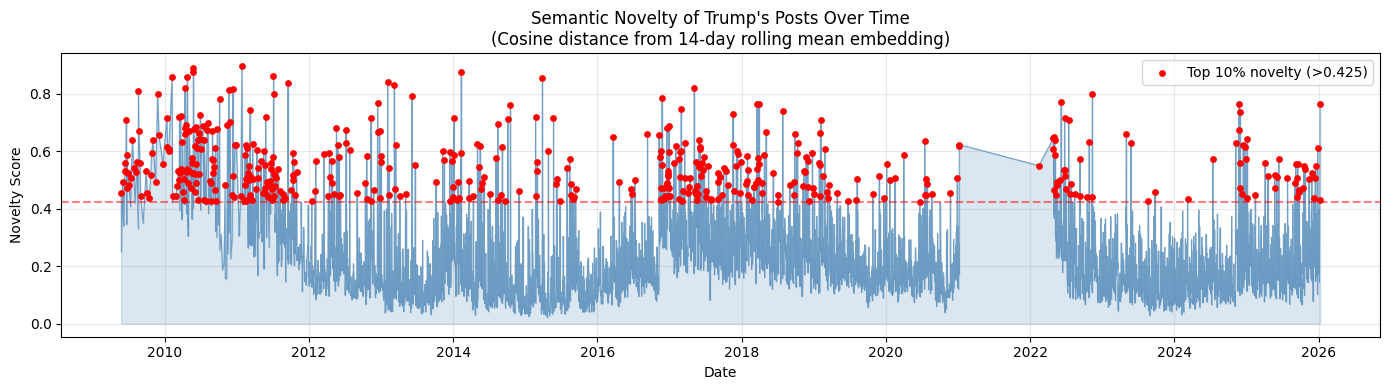

In [25]:
WINDOW = 14

daily_embeddings  = daily_embeddings.sort_values("date_only").reset_index(drop=True)
emb_matrix_sorted = daily_embeddings[emb_cols].values

novelty_scores = [np.nan] * WINDOW
for i in range(WINDOW, len(emb_matrix_sorted)):
    today    = emb_matrix_sorted[i]
    baseline = emb_matrix_sorted[i - WINDOW : i].mean(axis=0)
    novelty_scores.append(cosine_distance(today, baseline))

daily_embeddings["novelty_score"] = novelty_scores

print("Novelty score stats:")
print(daily_embeddings["novelty_score"].describe())

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_embeddings["date_only"], daily_embeddings["novelty_score"],
        linewidth=0.8, color="steelblue", alpha=0.7)
ax.fill_between(daily_embeddings["date_only"], daily_embeddings["novelty_score"],
                alpha=0.2, color="steelblue")
threshold = daily_embeddings["novelty_score"].quantile(0.9)
high      = daily_embeddings[daily_embeddings["novelty_score"] >= threshold]
ax.scatter(high["date_only"], high["novelty_score"],
           color="red", s=15, zorder=5, label=f"Top 10% novelty (>{threshold:.3f})")
ax.axhline(threshold, color="red", linestyle="--", alpha=0.5)
ax.set_title("Semantic Novelty of Trump's Posts Over Time\n"
             "(Cosine distance from 14-day rolling mean embedding)", fontsize=12)
ax.set(xlabel="Date", ylabel="Novelty Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "novelty_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### 5e — UMAP Visualisation

UMAP (McInnes et al., 2018) projects 384 dimensions to 2D while preserving
local structure. Three plots:
1. Coloured by K-Means cluster — validates semantic coherence
2. **Coloured by next-day S&P return** — the key EDA plot
3. Coloured by platform (X vs Truth Social)

> **Runtime:** ~5-10 minutes for 90k points. Cached after first run.

In [26]:
UMAP_CACHE = OUTPUT_DIR / "umap_2d.npy"

if UMAP_CACHE.exists():
    print("Loading cached UMAP projection...")
    umap_2d = np.load(UMAP_CACHE)
else:
    print("Fitting UMAP (this will take several minutes)...")
    reducer = umap.UMAP(
        n_components=2, n_neighbors=30, min_dist=0.1,
        metric="cosine", random_state=42, verbose=True,
    )
    umap_2d = reducer.fit_transform(embeddings)
    np.save(UMAP_CACHE, umap_2d)
    print(f"Saved to {UMAP_CACHE}")

originals["umap_x"] = umap_2d[:, 0]
originals["umap_y"] = umap_2d[:, 1]
print(f"UMAP shape: {umap_2d.shape}")

Fitting UMAP (this will take several minutes)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sun Apr 12 21:30:23 2026 Construct fuzzy simplicial set
Sun Apr 12 21:30:23 2026 Finding Nearest Neighbors
Sun Apr 12 21:30:23 2026 Building RP forest with 19 trees
Sun Apr 12 21:30:31 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	Stopping threshold met -- exiting after 4 iterations
Sun Apr 12 21:30:59 2026 Finished Nearest Neighbor Search
Sun Apr 12 21:31:04 2026 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  11%| █          22/200 [00:05]

	completed  20  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  90%| █████████  181/200 [00:44]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:49]

Sun Apr 12 21:32:27 2026 Finished embedding
Saved to c:\Dev\nlp-final-project\3_feature_engineering\features\umap_2d.npy
UMAP shape: (74742, 2)


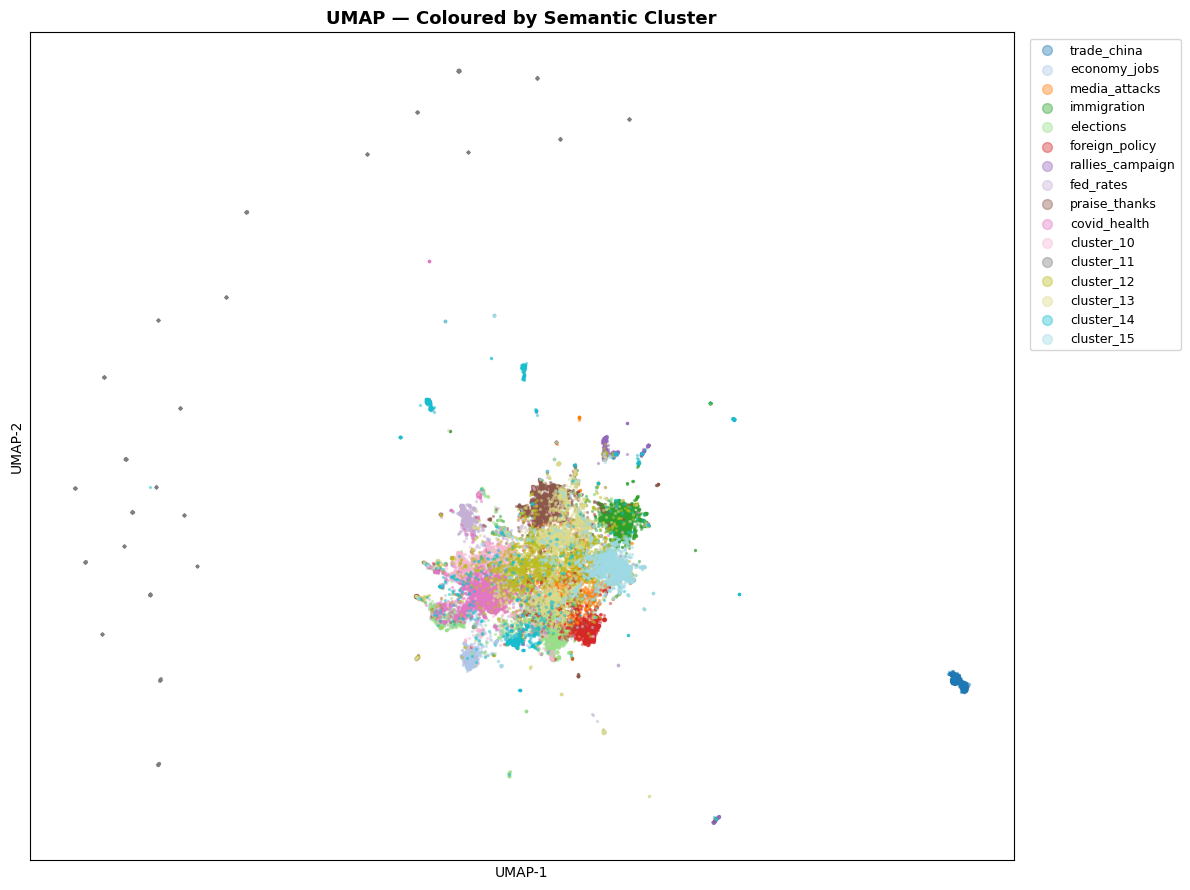

In [27]:
# Plot 1 — Coloured by cluster
N_PLOT  = min(30_000, len(originals))
plot_df = originals.sample(N_PLOT, random_state=42)

unique_clusters = sorted(plot_df["cluster_kmeans"].unique())
cmap   = plt.get_cmap("tab20", len(unique_clusters))
colors = {c: cmap(i) for i, c in enumerate(unique_clusters)}

fig, ax = plt.subplots(figsize=(12, 9))
for c in unique_clusters:
    sub   = plot_df[plot_df["cluster_kmeans"] == c]
    label = CLUSTER_LABELS.get(c, f"cluster_{c}")
    ax.scatter(sub["umap_x"], sub["umap_y"],
               s=2, alpha=0.4, color=colors[c], label=label, rasterized=True)
ax.legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_title("UMAP — Coloured by Semantic Cluster", fontsize=13, fontweight="bold")
ax.set(xlabel="UMAP-1", ylabel="UMAP-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

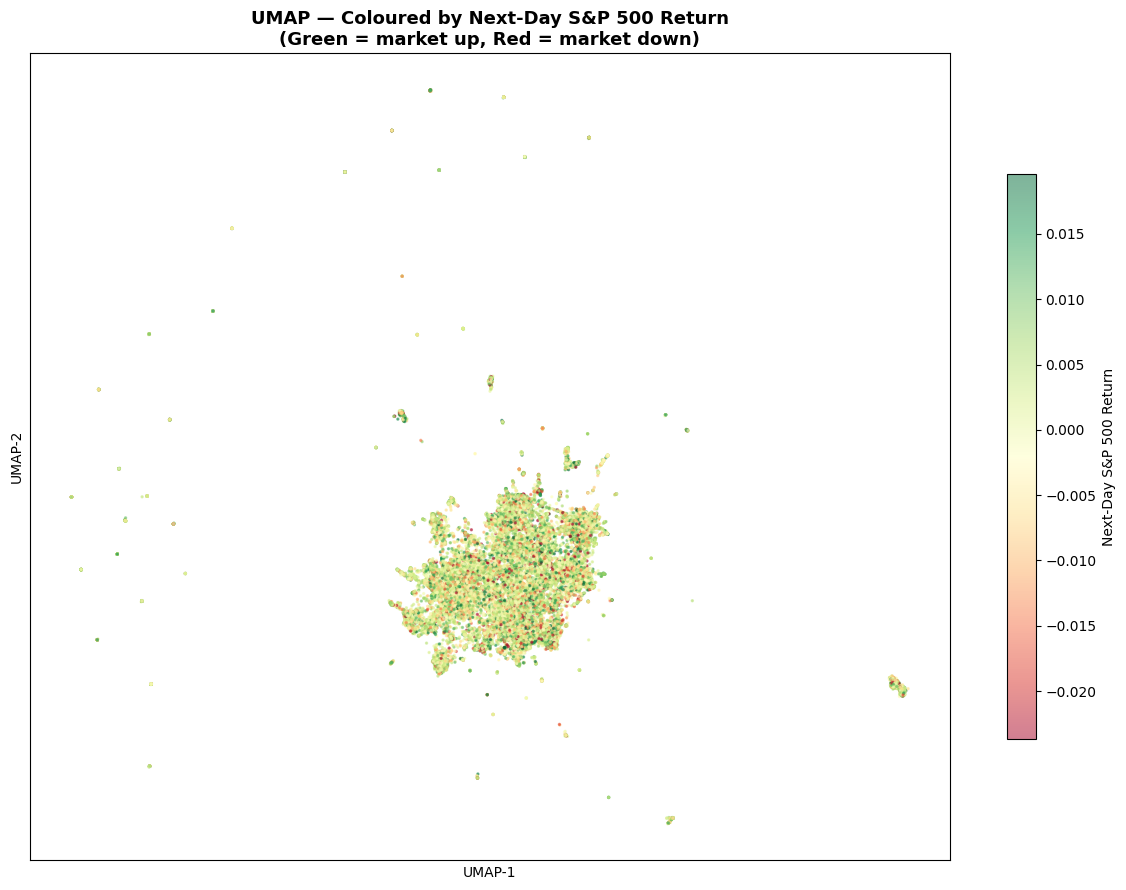

In [ ]:
# Plot 2 — Coloured by next-day S&P 500 return
sp_lookup = sp[["date", "next_log_return"]].copy()
sp_lookup["date_only"] = pd.to_datetime(sp_lookup["date"]).dt.normalize()

# Fix: ensure originals date_only is also datetime, not plain date objects
originals["date_only"] = pd.to_datetime(originals["date_only"])

originals_plot = originals.merge(
    sp_lookup[["date_only", "next_log_return"]], on="date_only", how="left"
).dropna(subset=["next_log_return"])

N_PLOT   = min(30_000, len(originals_plot))
plot_df2 = originals_plot.sample(N_PLOT, random_state=42)

ret_clipped = plot_df2["next_log_return"].clip(
    plot_df2["next_log_return"].quantile(0.02),
    plot_df2["next_log_return"].quantile(0.98),
)

fig, ax = plt.subplots(figsize=(12, 9))
sc = ax.scatter(
    plot_df2["umap_x"], plot_df2["umap_y"],
    c=ret_clipped, cmap="RdYlGn", s=2, alpha=0.5, rasterized=True,
    vmin=ret_clipped.min(), vmax=ret_clipped.max(),
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("Next-Day S&P 500 Return", fontsize=10)
ax.set_title("UMAP — Coloured by Next-Day S&P 500 Return\n"
             "(Green = market up, Red = market down)",
             fontsize=13, fontweight="bold")
ax.set(xlabel="UMAP-1", ylabel="UMAP-2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_by_return.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# from:
originals["date_only"] = originals["date"].dt.date

# to:
originals["date_only"] = originals["date"].dt.normalize()

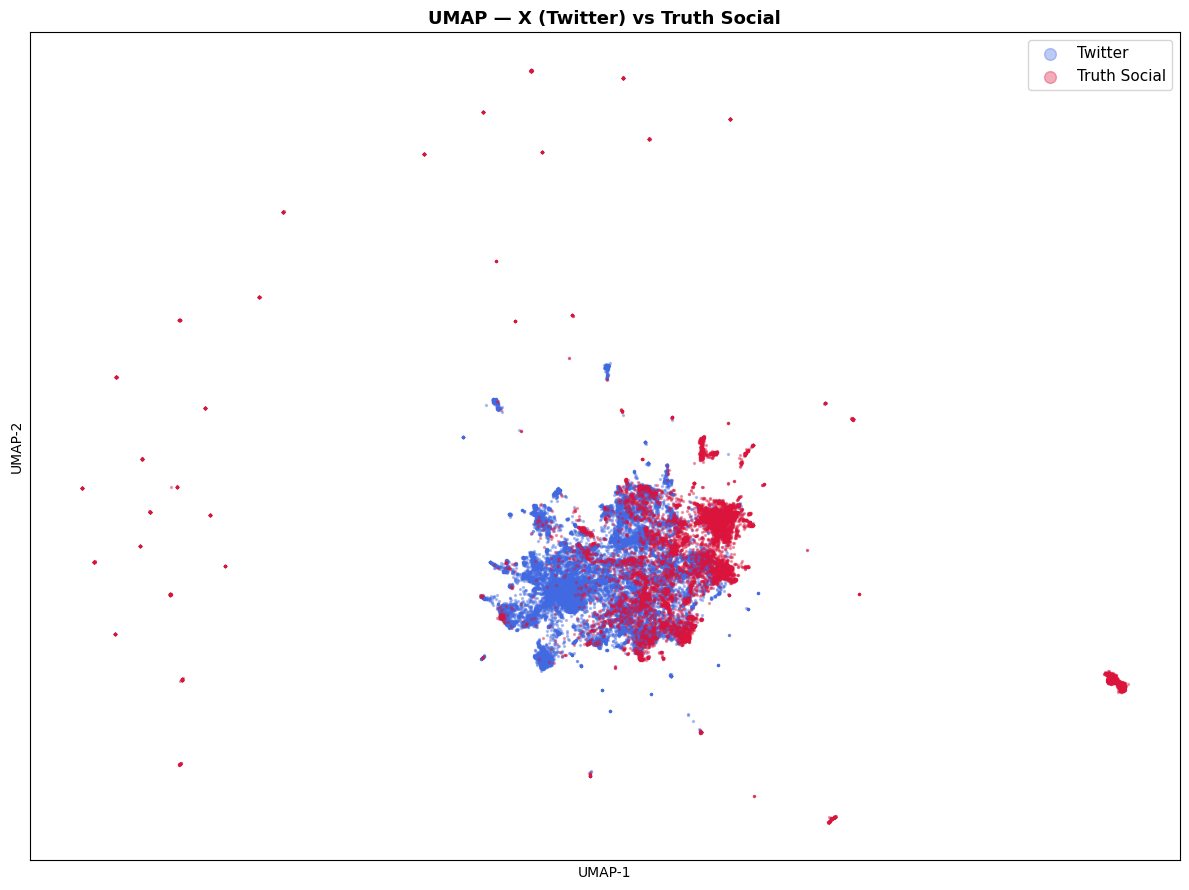

In [32]:
# Plot 3 — X (Twitter) vs Truth Social
if "platform" in originals.columns:
    N_PLOT   = min(30_000, len(originals))
    plot_df3 = originals.sample(N_PLOT, random_state=42)
    pal      = {"Twitter": "royalblue", "Truth Social": "crimson"}

    fig, ax = plt.subplots(figsize=(12, 9))
    for p in plot_df3["platform"].unique():
        sub = plot_df3[plot_df3["platform"] == p]
        ax.scatter(sub["umap_x"], sub["umap_y"],
                   s=2, alpha=0.35, label=p,
                   color=pal.get(p, "grey"), rasterized=True)
    ax.legend(markerscale=6, fontsize=11)
    ax.set_title("UMAP — X (Twitter) vs Truth Social", fontsize=13, fontweight="bold")
    ax.set(xlabel="UMAP-1", ylabel="UMAP-2")
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "umap_by_platform.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## 6 — Final Merge & Save

**Key design choice:** tweet features on day `t` are matched to *next-day* (`t+1`)
market returns via the pre-shifted `next_log_return` column. This avoids look-ahead bias.

In [33]:
# Standardise merge keys to tz-naive date
sp["date_only"]             = pd.to_datetime(sp["date"]).dt.normalize()
daily_features["date_only"] = pd.to_datetime(daily_features["date_only"]).dt.normalize()

# Embedding metadata: novelty, diversity, dominant cluster + one-hot dummies
emb_meta = daily_embeddings[["date_only", "emb_diversity", "dominant_cluster", "novelty_score"]].copy()
emb_meta["date_only"] = pd.to_datetime(emb_meta["date_only"]).dt.normalize()
cluster_dummies = pd.get_dummies(emb_meta["dominant_cluster"], prefix="cluster")
emb_meta = pd.concat([emb_meta, cluster_dummies], axis=1)

# Merge everything
feature_matrix = (
    sp
    .merge(daily_features, on="date_only", how="left")
    .merge(emb_meta,       on="date_only", how="left")
)

# Drop rows with no tweet data (weekends / pre-dataset dates)
feature_matrix = feature_matrix.dropna(subset=["vader_mean"])

print("Final feature matrix shape:", feature_matrix.shape)
feature_matrix.head()

Final feature matrix shape: (3526, 79)


,date,Close,High,Low,Open,Volume,log_return,abs_return,intraday_range,next_log_return,market_up,next_market_up,return_lag1,return_lag2,vol_5d,vol_20d,date_only,post_count,vader_mean,vader_std,vader_max_pos,vader_max_neg,finbert_mean,finbert_std,caps_ratio_mean,exclamation_mean,exclamation_max,max_engagement,mean_word_count,topic_trade,topic_fed,topic_energy,topic_tax,topic_sanctions,topic_market_direct,topic_immigration,topic_geopolitics,post_count_premarket,vader_mean_premarket,vader_std_premarket,vader_max_pos_premarket,vader_max_neg_premarket,finbert_mean_premarket,finbert_std_premarket,caps_ratio_mean_premarket,exclamation_mean_premarket,exclamation_max_premarket,max_engagement_premarket,mean_word_count_premarket,topic_trade_premarket,topic_fed_premarket,topic_energy_premarket,topic_tax_premarket,topic_sanctions_premarket,topic_market_direct_premarket,topic_immigration_premarket,topic_geopolitics_premarket,vader_3d_rolling,vader_7d_rolling,vader_momentum,emb_diversity,dominant_cluster,novelty_score,cluster_cluster_10,cluster_cluster_11,cluster_cluster_12,cluster_cluster_13,cluster_cluster_14,cluster_cluster_15,cluster_covid_health,cluster_economy_jobs,cluster_elections,cluster_fed_rates,cluster_foreign_policy,cluster_immigration,cluster_media_attacks,cluster_praise_thanks,cluster_rallies_campaign,cluster_trade_china
0,2009-05-04,907.2400,907.8500,879.2100,879.2100,7038840000,0.0339,0.0339,0.0326,-0.0038,1,0,NaN,NaN,NaN,NaN,2009-05-04,2.0000,0.6483,0.1737,0.7712,0.5255,0.0418,0.0046,0.0991,1.0000,1.0000,7.2786,22.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6483,0.6483,0.0000,0.0200,cluster_10,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2009-05-08,929.2300,930.1700,909.0300,909.0300,8163280000,0.0241,0.0241,0.0233,-0.0215,1,0,-0.0132,0.0174,0.0196,NaN,2009-05-08,2.0000,0.3234,0.4574,0.6468,0.0000,0.0508,0.0177,0.1200,0.5000,1.0000,3.8918,15.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.6468,NaN,0.6468,0.6468,0.0383,NaN,0.1196,1.0000,1.0000,3.8918,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4859,0.4859,-0.1625,0.0219,cluster_10,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,2009-05-12,908.3500,915.5700,896.4600,910.5200,6871750000,-0.0010,0.0010,0.0210,-0.0269,0,0,-0.0215,0.0241,0.0195,NaN,2009-05-12,2.0000,0.2404,0.3400,0.4809,0.0000,-0.1093,0.1675,0.0847,0.0000,0.0000,8.0864,20.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4041,0.4041,-0.1636,0.0249,cluster_12,NaN,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
7,2009-05-13,883.9200,905.4000,882.8000,905.4000,7091820000,-0.0269,0.0269,0.0250,0.0104,0,1,-0.0010,-0.0215,0.0203,NaN,2009-05-13,1.0000,0.7506,NaN,0.7506,0.7506,0.0848,NaN,0.0778,0.0000,0.0000,3.4657,16.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4382,0.4907,0.3125,0.0000,immigration,NaN,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
8,2009-05-14,893.0700,898.3600,882.5200,884.2400,6134870000,0.0104,0.0104,0.0179,-0.0114,1,0,-0.0269,-0.0010,0.0214,NaN,2009-05-14,1.0000,0.2023,NaN,0.2023,0.2023,0.0137,NaN,0.0500,0.0000,0.0000,3.7377,14.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3978,0.4330,-0.1955,0.0000,fed_rates,NaN,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [34]:
null_pct = feature_matrix.isnull().mean().sort_values(ascending=False)
print("Columns with >5% missing:")
print(null_pct[null_pct > 0.05])

Columns with >5% missing:
vader_std_premarket             0.4838
finbert_std_premarket           0.4838
mean_word_count_premarket       0.3267
topic_energy_premarket          0.3267
topic_tax_premarket             0.3267
topic_trade_premarket           0.3267
topic_fed_premarket             0.3267
vader_max_pos_premarket         0.3267
vader_max_neg_premarket         0.3267
post_count_premarket            0.3267
vader_mean_premarket            0.3267
caps_ratio_mean_premarket       0.3267
finbert_mean_premarket          0.3267
exclamation_mean_premarket      0.3267
exclamation_max_premarket       0.3267
topic_market_direct_premarket   0.3267
topic_sanctions_premarket       0.3267
topic_geopolitics_premarket     0.3267
topic_immigration_premarket     0.3267
max_engagement_premarket        0.3267
vader_std                       0.0615
finbert_std                     0.0615
dtype: float64


In [35]:
# Tweet-level features + embeddings + cluster labels + UMAP coords
originals.drop(columns=["emb_idx"], errors="ignore").to_pickle(
    OUTPUT_DIR / "tweets_features.pkl"
)

# Raw tweet embedding matrix
np.save(OUTPUT_DIR / "tweet_embeddings.npy", embeddings.astype(np.float32))

# Daily tweet features (sentiment, topics, rolling windows)
daily_features.to_csv(OUTPUT_DIR / "daily_features.csv", index=False)

# Daily mean embeddings (full 384-dim) + dates index
np.save(OUTPUT_DIR / "daily_mean_embeddings.npy", emb_matrix.astype(np.float32))
daily_embeddings[["date_only"]].to_csv(
    OUTPUT_DIR / "daily_mean_embeddings_dates.csv", index=False
)

# Pre-market daily embeddings
pre_cols = [c for c in daily_pre_embeddings.columns if c.startswith("pre_emb_")]
np.save(OUTPUT_DIR / "daily_premarket_embeddings.npy",
        daily_pre_embeddings[pre_cols].values.astype(np.float32))

# Final feature matrix — ready for modelling
feature_matrix.to_csv(OUTPUT_DIR / "feature_matrix.csv", index=False)

print("All outputs saved to:", OUTPUT_DIR)
print("\nFiles written:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:<48} {f.stat().st_size/1e6:>6.1f} MB")

All outputs saved to: c:\Dev\nlp-final-project\3_feature_engineering\features

Files written:
  cluster_selection.png                               0.1 MB
  daily_features.csv                                  1.8 MB
  daily_mean_embeddings.npy                           7.5 MB
  daily_mean_embeddings_dates.csv                     0.1 MB
  daily_premarket_embeddings.npy                      4.9 MB
  feature_matrix.csv                                  2.6 MB
  novelty_over_time.png                               0.2 MB
  tweet_embeddings.npy                              114.8 MB
  tweets_features.pkl                                85.0 MB
  umap_2d.npy                                         0.6 MB
  umap_by_cluster.png                                 0.2 MB
  umap_by_platform.png                                0.2 MB
  umap_by_return.png                                  0.2 MB


In [36]:
# 1. Tweet-level (pkl justified here — preserves list columns, embeddings index, etc.)
originals.to_pickle(OUTPUT_DIR / "tweets_features.pkl")

# 2. Daily features — merge embedding metadata in before saving
daily_features_full = daily_features.merge(
    daily_embeddings[["date_only", "emb_diversity", "dominant_cluster", "novelty_score"]],
    on="date_only", how="left"
)
daily_features_full.to_csv(OUTPUT_DIR / "daily_features.csv", index=False)

# 3. Final model-ready matrix (what your modelling notebook will actually load)
feature_matrix.to_csv(OUTPUT_DIR / "feature_matrix.csv", index=False)

# 4. Raw embeddings — numpy is the right format for a float matrix this size
np.save(OUTPUT_DIR / "tweet_embeddings.npy", embeddings.astype(np.float32))
np.save(OUTPUT_DIR / "daily_mean_embeddings.npy", emb_matrix.astype(np.float32))

---
## Summary of All Features

### Tweet-level (`tweets_features.pkl`)
| Feature | Description |
|---|---|
| `vader_compound` | VADER aggregate sentiment [-1, +1] |
| `vader_pos/neg/neu` | VADER class probabilities |
| `vader_label` | Categorical: positive / neutral / negative |
| `finbert_polarity` | FinBERT pos - neg score |
| `finbert_label` | FinBERT predicted class |
| `topic_trade` ... | Binary topic flags (8 topics) |
| `caps_ratio` | Fraction of alpha chars that are uppercase |
| `exclamation_count` | Number of `!` characters |
| `log_engagement` | log1p(favorites + reposts) |
| `is_premarket` | 1 if posted 4-9:29 AM ET |
| `cluster_kmeans` | K-Means cluster ID |
| `cluster_label` | Human-readable cluster name |
| `cluster_hdbscan` | HDBSCAN cluster ID (-1 = noise) |
| `umap_x / umap_y` | 2D UMAP coordinates |

### Daily-level (`daily_features.csv` + embedding files)
| Feature | Description |
|---|---|
| `post_count` | Number of original posts that day |
| `vader_mean / std` | Mean and std of VADER compound |
| `finbert_mean / std` | Mean and std of FinBERT polarity |
| `vader_3d/7d_rolling` | Rolling mean sentiment |
| `vader_momentum` | Today's sentiment vs 3-day average |
| `*_premarket` | All above, restricted to pre-market posts |
| `emb_diversity` | Within-day embedding std (topic breadth) |
| `novelty_score` | Cosine distance from 14-day rolling baseline |
| `dominant_cluster` | Most common K-Means cluster that day |
| `cluster_*` | One-hot encoded cluster dummies |

### Market targets (`feature_matrix.csv`)
| Feature | Description |
|---|---|
| `log_return` | Daily return |
| `next_log_return` | **Regression target** (next-day return) |
| `next_market_up` | **Classification target** (next-day direction) |
| `vol_5d / vol_20d` | Rolling realised volatility |
| `return_lag1/2` | Lagged returns (autocorrelation controls) |

### How to use daily mean embeddings in models
```python
from sklearn.decomposition import PCA
import numpy as np, pandas as pd

embs  = np.load("features/daily_mean_embeddings.npy")
dates = pd.read_csv("features/daily_mean_embeddings_dates.csv", parse_dates=["date_only"])
fm    = pd.read_csv("features/feature_matrix.csv", parse_dates=["date_only"])

# Reduce to 50 dimensions (typically retains >80% variance)
pca    = PCA(n_components=50, random_state=42)
emb_r  = pca.fit_transform(embs)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

emb_df = pd.DataFrame(emb_r, columns=[f"pc_{i}" for i in range(50)])
emb_df["date_only"] = dates["date_only"].values

combined = fm.merge(emb_df, on="date_only", how="left")
```